# 14 · ELBE — a perda esperada dos contratos **já em *default***

Para o contrato que ainda não quebrou, a perda esperada é `PD × LGD × EAD`. Para o que
**já quebrou**, não há PD: o evento aconteceu. O que resta é outra pergunta —

> *do saldo que ainda está lá, quanto ainda vai virar perda?*

Essa é a **ELBE** (*expected loss best estimate*), e ela **muda com o tempo em *default***:
um contrato que quebrou ontem tem quase tudo a recuperar; um que está há três anos em
cobrança já entregou o que tinha para entregar, e o que sobrou é quase todo perda.

É o parâmetro do **estágio 3** do ECL e o insumo da LGD *in default* — e é onde mora um
erro clássico, que este tutorial existe para desmontar: **`1 − r̄(t)` não é a ELBE**.

Roteiro:

1. o problema, e por que a ELBE é uma **razão**
2. o formato de entrada — exposição inicial + colunas de LGD por mês
3. a **curva de recuperação** e por que ela precisa ser encadeada
4. o **horizonte de *workout***
5. a tabela ELBE, coluna a coluna
6. como se fixa a recuperação do ciclo completo (`ultimate`)
7. **desconto**, *add-on* de perda inesperada e piso
8. estornos e monotonicidade
9. por segmento, aplicação à carteira viva e registro

| tutoriais irmãos | |
|---|---|
| [`12`](12_tutorial_ecl.ipynb) | a perda esperada **ponta a ponta** |
| [`13`](13_tutorial_pd_lifetime.ipynb) | **PD lifetime** — quando o risco se materializa |
| [`15`](15_tutorial_ccf.ipynb) | **CCF/EAD** — sobre qual exposição a perda incide |

> Metodologia e referências (EBA/GL/2017/16 §6, ECB *Guide to Internal Models* §6.4):
> [`docs/credit-risk/ecl.md`](../../docs/credit-risk/ecl.md).

In [1]:
# --- Bootstrap: torna o pacote `yggdrasil` importável a partir do repositório,
# sem `pip install`. Procura a raiz do repo (a pasta que contém `yggdrasil/`) por
# vários âncoras — o caminho do próprio notebook (VS Code expõe `__vsc_ipynb_file__`),
# o diretório atual, os diretórios do sys.path e, no Databricks, o caminho via
# dbutils — subindo até achá-la, e a insere no sys.path. Cobre Jupyter/VS Code
# local e Databricks; se o pacote já estiver importável, é inócuo.
import sys
from pathlib import Path

def _find_yggdrasil_root():
    _anchors = []
    for _n in ("__vsc_ipynb_file__", "__file__", "__session__"):
        _v = globals().get(_n)
        if _v:
            _anchors.append(Path(str(_v)))
    _anchors.append(Path.cwd())
    _anchors += [Path(_p) for _p in sys.path if _p not in ("", ".")]
    for _a in _anchors:
        try:
            _a = _a.resolve()
        except Exception:
            continue
        for _b in (_a, *_a.parents):
            if (_b / "yggdrasil" / "__init__.py").is_file():
                return _b
    try:  # fallback Databricks: caminho do próprio notebook
        _nbp = (dbutils.notebook.entry_point.getDbutils()  # noqa: F821
                .notebook().getContext().notebookPath().get())
        for _pref in ("/Workspace", ""):
            for _b in Path(_pref + _nbp).parents:
                if (_b / "yggdrasil" / "__init__.py").is_file():
                    return _b
    except Exception:
        pass
    return None

_ygg_root = _find_yggdrasil_root()
if _ygg_root and str(_ygg_root) not in sys.path:
    sys.path.insert(0, str(_ygg_root))

In [2]:
%matplotlib inline
import os
os.environ.setdefault("MLFLOW_ALLOW_FILE_STORE", "true")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 30)

---
## 1 · O problema: a ELBE é uma **razão**, e sobe com o tempo

Chame de `EAD₀` a exposição na data do *default* e de `r(t)` a recuperação acumulada até
`t` meses depois, como fração de `EAD₀`. Então:

- já foi recuperado: `EAD₀ · r(t)`
- **saldo remanescente**: `EAD₀ · (1 − r(t))`
- perda do ciclo completo: `EAD₀ · (1 − r(T*))`, com `T*` o fim do *workout*

A ELBE é a perda que **ainda falta**, medida **sobre o saldo remanescente**:

$$ELBE(t) = \frac{EAD_0 \cdot (1 - \bar r(T^*))}{EAD_0 \cdot (1 - \bar r(t))} = \frac{1 - \bar r(T^*)}{1 - \bar r(t)}$$

Como o denominador encolhe mais rápido que o numerador, a ELBE **sobe** com o tempo em
*default* — mesmo quando a recuperação total é boa. Reportar `1 − r̄(t)` no lugar dela é o
erro clássico: isso é a **LGD acumulada até `t`**, uma grandeza *retrospectiva* (quanto já
se perdeu), não a melhor estimativa do que ainda falta.

In [3]:
def defaults_sinteticos(n=800, meses=37, seed=5):
    '''Contratos em default com DGP conhecido.

    Recuperação exponencial com assíntota por segmento, CENSURA à direita (os defaults
    recentes ainda não chegaram aos meses altos) e — de propósito — uma correlação
    realista: caso difícil fica mais tempo em cobrança. É essa correlação que quebra a
    média direta da acumulada, como a seção 3 mostra.
    '''
    rng = np.random.default_rng(seed)
    segmento = np.where(rng.uniform(size=n) < 0.6, "cartao", "consignado")
    ead0 = rng.lognormal(8.5, 0.6, n)
    qualidade = rng.uniform(0.0, 1.0, n)                     # 1 = recupera bem
    assintota = np.clip(np.where(segmento == "cartao", 0.20, 0.55) + 0.35 * qualidade, 0, 0.95)
    velocidade = np.where(segmento == "cartao", 0.10, 0.18)
    # caso BOM resolve rápido e sai de observação; caso RUIM segue em cobrança
    observado_ate = np.clip((3 + 34 * (1 - qualidade) + rng.normal(0, 4, n)).astype(int), 3, meses)
    t = np.arange(meses)
    r = assintota[:, None] * (1.0 - np.exp(-velocidade[:, None] * t[None, :]))
    r = np.where(t[None, :] < observado_ate[:, None], r, np.nan)
    out = pd.DataFrame({"id_contrato": [f"D{i:04d}" for i in range(n)],
                        "segmento": segmento, "exposicao_inicial": ead0})
    for k in range(meses):
        out[f"lgd_m{k}"] = 1.0 - r[:, k]
    return out

defaults = defaults_sinteticos()
print(f"{len(defaults)} contratos em default | exposição total: "
      f"{defaults['exposicao_inicial'].sum():,.0f}")
defaults[["id_contrato", "segmento", "exposicao_inicial",
          "lgd_m0", "lgd_m6", "lgd_m12", "lgd_m36"]].head(4).round(3)

800 contratos em default | exposição total: 4,782,804


,id_contrato,segmento,exposicao_inicial,lgd_m0,lgd_m6,lgd_m12,lgd_m36
0,D0000,consignado,4112.848,1.0,NaN,NaN,NaN
1,D0001,consignado,11055.580,1.0,0.507,0.340,NaN
2,D0002,cartao,2656.568,1.0,0.866,0.793,NaN
3,D0003,cartao,1947.796,1.0,0.811,0.707,NaN


---
## 2 · O formato de entrada

Uma linha por contrato em *default*, com a **exposição inicial** e as **colunas de LGD por
mês em *default***: `lgd_m0`, `lgd_m1`, …, `lgd_mN`. A coluna `lgd_mt` é a LGD que se
realizaria se a cobrança parasse naquele mês — ou seja, `lgd(t) = 1 − r(t)`.

`NaN` no fim da série é **censura** (o contrato ainda não chegou àquele mês). O sufixo
numérico é o que ordena — não a ordem das colunas no DataFrame, que costuma vir
desordenada de um `pivot`.

In [4]:
from yggdrasil.credit_risk.ecl import detect_month_columns

cols, meses = detect_month_columns(defaults, prefix="lgd_m")
print(f"{len(cols)} colunas detectadas: {cols[:3]} ... {cols[-1]}")
print(f"meses: {meses[:5]} ... {meses[-1]}")

# a ordenação é pelo SUFIXO, não pela posição
bagunçado = defaults[["exposicao_inicial", "lgd_m10", "lgd_m2", "lgd_m0"]]
print("\nordem no frame:", list(bagunçado.columns)[1:])
print("ordem detectada:", detect_month_columns(bagunçado)[0])

37 colunas detectadas: ['lgd_m0', 'lgd_m1', 'lgd_m2'] ... lgd_m36
meses: [0 1 2 3 4] ... 36

ordem no frame: ['lgd_m10', 'lgd_m2', 'lgd_m0']
ordem detectada: ['lgd_m0', 'lgd_m2', 'lgd_m10']


As colunas podem vir em **quatro formatos**, e o módulo aceita todos:

| `kind` | as colunas são | `unit` | valores em |
|---|---|---|---|
| `"lgd"` (padrão) | LGD remanescente `1 − r(t)` | `"taxa"` (padrão) | fração de `EAD₀` |
| `"recuperacao"` | recuperação acumulada `r(t)` | `"valor"` | moeda |

In [5]:
from yggdrasil.credit_risk.ecl import elbe_table

ead0 = defaults["exposicao_inicial"].to_numpy()
como_taxa = defaults[["exposicao_inicial"]].copy()
como_valor = defaults[["exposicao_inicial"]].copy()
for c in cols:
    rec = 1.0 - defaults[c]
    como_taxa[c.replace("lgd_m", "rec_m")] = rec
    como_valor[c.replace("lgd_m", "rec_m")] = rec * ead0

referencia = elbe_table(defaults).lgd
pd.DataFrame([
    {"entrada": "lgd / taxa (padrão)", "LGD do ciclo": referencia},
    {"entrada": "recuperação / taxa",
     "LGD do ciclo": elbe_table(como_taxa, lgd_prefix="rec_m", kind="recuperacao").lgd},
    {"entrada": "recuperação / valor",
     "LGD do ciclo": elbe_table(como_valor, lgd_prefix="rec_m", kind="recuperacao",
                                unit="valor").lgd},
]).round(6)

,entrada,LGD do ciclo
0,lgd / taxa (padrão),0.546107
1,recuperação / taxa,0.546107
2,recuperação / valor,0.546107


---
## 3 · A curva de recuperação — por que ela precisa ser **encadeada**

Aqui está o ponto delicado. Como os *defaults* recentes ainda não chegaram aos meses altos,
o conjunto de contratos observados **muda de mês para mês**. Fazer a média direta da
recuperação acumulada de cada mês mistura coortes diferentes.

E não é um detalhe teórico: quando o tempo de observação se **correlaciona** com a
qualidade da recuperação — e ele se correlaciona, porque **caso difícil fica mais tempo em
cobrança** — a média direta produz uma curva que **cai**. O que não faz sentido nenhum para
uma acumulada.

In [6]:
# A média direta (ERRADA): média ponderada da acumulada, mês a mês, sobre quem foi observado.
rec = 1.0 - defaults[cols].to_numpy()
obs = ~np.isnan(rec)
peso = np.where(obs, ead0[:, None], 0.0)
media_direta = np.nansum(np.where(obs, rec * ead0[:, None], 0.0), axis=0) / peso.sum(axis=0)

from yggdrasil.credit_risk.ecl import recovery_curve
curva = recovery_curve(defaults)

comparacao = pd.DataFrame({
    "n_contratos": curva["n_contratos"],
    "média direta (ERRADA)": media_direta,
    "encadeada (correta)": curva["recuperacao_acumulada"],
}, index=curva.index)
print("a média direta é monotônica?", pd.Series(media_direta).is_monotonic_increasing)
print("a encadeada é monotônica? .. ", curva["recuperacao_acumulada"].is_monotonic_increasing)
comparacao.iloc[[0, 6, 12, 18, 24, 30, 36]].round(4)

a média direta é monotônica? False
a encadeada é monotônica? ..  True


,n_contratos,média direta (ERRADA),encadeada (correta)
mes_default,,,
0,800,0.0000,0.0000
6,713,0.2663,0.2718
12,582,0.3565,0.3805
18,415,0.3736,0.4257
24,297,0.3688,0.4451
30,160,0.3405,0.4539
36,35,0.3354,0.4579


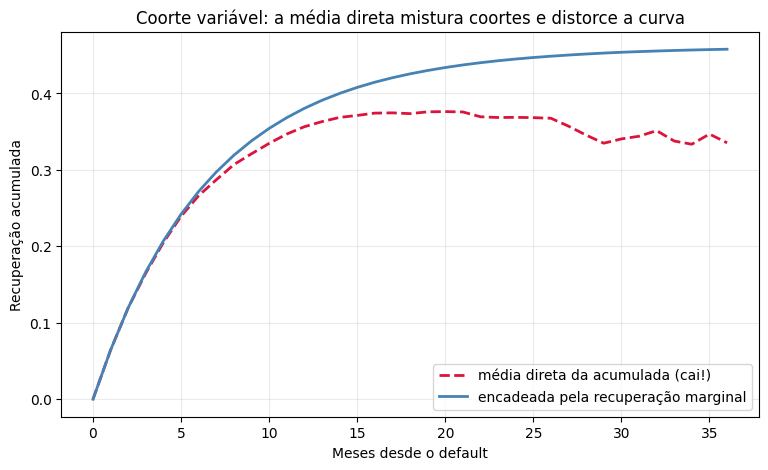

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(comparacao.index, comparacao["média direta (ERRADA)"], lw=2, color="crimson",
        ls="--", label="média direta da acumulada (cai!)")
ax.plot(comparacao.index, comparacao["encadeada (correta)"], lw=2, color="steelblue",
        label="encadeada pela recuperação marginal")
ax.set_xlabel("Meses desde o default"); ax.set_ylabel("Recuperação acumulada")
ax.set_title("Coorte variável: a média direta mistura coortes e distorce a curva")
ax.grid(alpha=.25); ax.legend()
plt.show()

O tratamento correto é encadear a recuperação **marginal** — o análogo do estimador
produto-limite usado em sobrevivência:

$$\Delta \bar r(t) = \frac{\sum_{i \in obs(t)} EAD_{0i}\,\big(r_i(t) - r_i(t-1)\big)}{\sum_{i \in obs(t)} EAD_{0i}} \qquad\qquad \bar r(t) = \sum_{k \le t} \Delta \bar r(k)$$

Cada mês é estimado **nos contratos que efetivamente chegaram nele**, e a curva fica
monotônica por construção (dadas recuperações marginais não-negativas).

In [8]:
curva[["n_contratos", "exposicao_observada", "exposicao_inicial",
       "recuperacao_acumulada", "recuperacao_marginal",
       "exposicao_remanescente", "lgd_acumulada"]].iloc[[0, 3, 6, 12, 24, 36]].round(4)

,n_contratos,exposicao_observada,exposicao_inicial,recuperacao_acumulada,recuperacao_marginal,exposicao_remanescente,lgd_acumulada
mes_default,,,,,,,
0,800,4.782804e+06,4.782804e+06,0.0000,0.0000,4.782804e+06,1.0000
3,758,4.527200e+06,4.782804e+06,0.1667,0.0470,3.985336e+06,0.8333
6,713,4.262473e+06,4.782804e+06,0.2718,0.0298,3.482693e+06,0.7282
12,582,3.509984e+06,4.782804e+06,0.3805,0.0122,2.962736e+06,0.6195
24,297,1.729386e+06,4.782804e+06,0.4451,0.0023,2.654102e+06,0.5549
36,35,2.277516e+05,4.782804e+06,0.4579,0.0005,2.592802e+06,0.5421


Repare em duas colunas distintas: `exposicao_observada` é a exposição da coorte que chegou
àquele mês (cai com a censura) e `exposicao_inicial` é a da **coorte inteira** (constante).
A `exposicao_remanescente` é lida da curva sobre a coorte inteira, para que a leitura seja
comparável entre horizontes.

### A alternativa: coorte fechada

`cohort="complete"` usa só os contratos observados **até o último mês**. É mais simples de
auditar — sem censura, sem encadeamento — mas descarta os *defaults* recentes e, com isso,
só enxerga o passado distante.

In [9]:
encadeada = elbe_table(defaults, cohort="chained")
fechada = elbe_table(defaults, cohort="complete")
pd.DataFrame([
    {"coorte": "chained (padrão)", "n contratos": encadeada.meta["n_contratos"],
     "LGD do ciclo": encadeada.lgd, "workout": encadeada.workout},
    {"coorte": "complete", "n contratos": fechada.meta["n_contratos"],
     "LGD do ciclo": fechada.lgd, "workout": fechada.workout},
]).round(4)

,coorte,n contratos,LGD do ciclo,workout
0,chained (padrão),800,0.5461,30
1,complete,35,0.6694,29


> No nosso DGP a coorte fechada é justamente a dos **casos difíceis** (os que ficaram mais
> tempo em cobrança), e por isso a LGD dela vem mais alta. É exatamente o viés de seleção
> que o encadeamento evita — e é o motivo de `chained` ser o padrão.

---
## 4 · O horizonte de *workout*

A recuperação não é infinita: em algum mês a curva achata. `workout_horizon` localiza o
**menor `t`** tal que o que ainda se recupera depois dele é menor ou igual a `tol`:

$$\bar r(T_{max}) - \bar r(t) \le tol$$

É a leitura operacional do critério do *ECB Guide to Internal Models* (§6.4): "o momento
após o *default* a partir do qual a evolução das taxas de recuperação acumuladas é
praticamente nula".

In [10]:
from yggdrasil.credit_risk.ecl import workout_horizon

sensibilidade = pd.DataFrame([
    {"tol": tol, "horizonte T*": workout_horizon(curva, tol=tol),
     "recuperação em T*": float(curva.loc[workout_horizon(curva, tol=tol),
                                          "recuperacao_acumulada"])}
    for tol in (0.0005, 0.001, 0.005, 0.01, 0.02, 0.05)
])
sensibilidade.round(5)

,tol,horizonte T*,recuperação em T*
0,0.0005,35,0.45741
1,0.0010,35,0.45741
2,0.0050,30,0.45389
3,0.0100,26,0.44876
4,0.0200,22,0.44025
5,0.0500,15,0.40794


Quanto mais frouxa a tolerância, **mais cedo** se declara o fim do *workout* — e menor a
recuperação reconhecida (logo, maior a LGD). É uma escolha de política, e por isso ela é
parâmetro, não constante.

`min_contratos` protege a leitura: não se declara o fim da recuperação olhando para três
contratos.

In [11]:
for minimo in (1, 50, 200):
    T = workout_horizon(curva, tol=0.005, min_contratos=minimo)
    n = int(curva.loc[T, "n_contratos"])
    print(f"min_contratos={minimo:3d} -> T* = {T:2d} meses (base naquele mês: {n} contratos)")

min_contratos=  1 -> T* = 30 meses (base naquele mês: 160 contratos)
min_contratos= 50 -> T* = 29 meses (base naquele mês: 181 contratos)
min_contratos=200 -> T* = 25 meses (base naquele mês: 271 contratos)


---
## 5 · A tabela ELBE

In [12]:
tab = elbe_table(defaults, exposure_col="exposicao_inicial", lgd_prefix="lgd_m",
                 kind="lgd", tol=0.005)
tab

ELBETable(T*=30, LGD=54.61%, ELBE(0)=54.61%, ELBE(T*)=100.00%)

In [13]:
tab.frame[["n_contratos", "recuperacao_acumulada", "recuperacao_marginal",
           "exposicao_remanescente", "lgd_acumulada", "elbe",
           "perda_esperada_remanescente"]].iloc[[0, 3, 6, 12, 24, 36]].round(4)

,n_contratos,recuperacao_acumulada,recuperacao_marginal,exposicao_remanescente,lgd_acumulada,elbe,perda_esperada_remanescente
mes_default,,,,,,,
0,800,0.0000,0.0000,4.782804e+06,1.0000,0.5461,2.611923e+06
3,758,0.1667,0.0470,3.985336e+06,0.8333,0.6554,2.611923e+06
6,713,0.2718,0.0298,3.482693e+06,0.7282,0.7500,2.611923e+06
12,582,0.3805,0.0122,2.962736e+06,0.6195,0.8816,2.611923e+06
24,297,0.4451,0.0023,2.654102e+06,0.5549,0.9841,2.611923e+06
36,35,0.4579,0.0005,2.592802e+06,0.5421,1.0000,2.592802e+06


### As três leituras da tabela

1. **`ELBE(0) = LGD do ciclo completo`** — no mês do *default* nada foi recuperado, então o
   que resta perder sobre o saldo remanescente é a LGD inteira;
2. **a ELBE sobe** — e a `lgd_acumulada` (que é `1 − r̄(t)`) **desce**. Elas caminham em
   direções opostas, e confundi-las é o erro clássico;
3. **`n_contratos` cai** — é a censura, tratada e visível.

In [14]:
f = tab.frame
print(f"ELBE(0) = {f['elbe'].iloc[0]:.4%}  |  LGD do ciclo = {tab.lgd:.4%}  "
      f"-> iguais: {np.isclose(f['elbe'].iloc[0], tab.lgd)}")
print(f"ELBE é monotônica até T*: {f.loc[:tab.workout, 'elbe'].is_monotonic_increasing}")
print(f"lgd_acumulada é DEcrescente: {f['lgd_acumulada'].is_monotonic_decreasing}")
print(f"\nELBE({tab.workout}) = {tab.elbe_at(tab.workout):.4%}   <- veja a seção 6")

ELBE(0) = 54.6107%  |  LGD do ciclo = 54.6107%  -> iguais: True
ELBE é monotônica até T*: True
lgd_acumulada é DEcrescente: True

ELBE(30) = 100.0000%   <- veja a seção 6


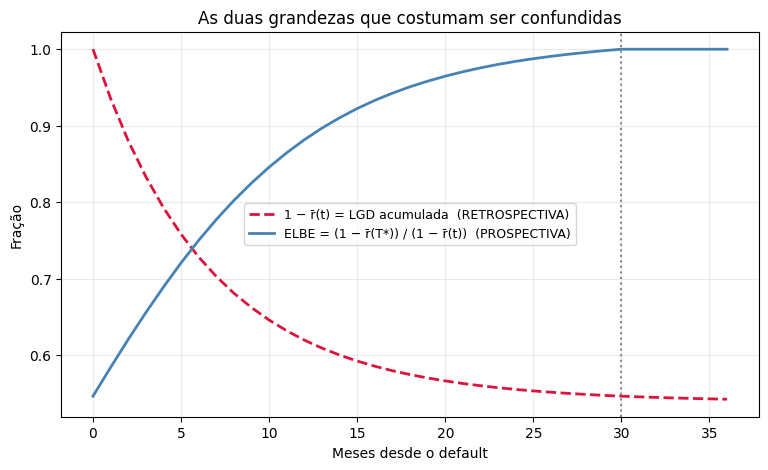

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(f.index, f["lgd_acumulada"], lw=2, color="crimson", ls="--",
        label="1 − r̄(t) = LGD acumulada  (RETROSPECTIVA)")
ax.plot(f.index, f["elbe"], lw=2, color="steelblue",
        label="ELBE = (1 − r̄(T*)) / (1 − r̄(t))  (PROSPECTIVA)")
ax.axvline(tab.workout, color="#888", ls=":", lw=1.5)
ax.annotate(f"workout = {tab.workout}", xy=(tab.workout, 0.05), xytext=(5, 0),
            textcoords="offset points", fontsize=9, color="#888")
ax.set_xlabel("Meses desde o default"); ax.set_ylabel("Fração")
ax.set_title("As duas grandezas que costumam ser confundidas")
ax.grid(alpha=.25); ax.legend(fontsize=9)
plt.show()

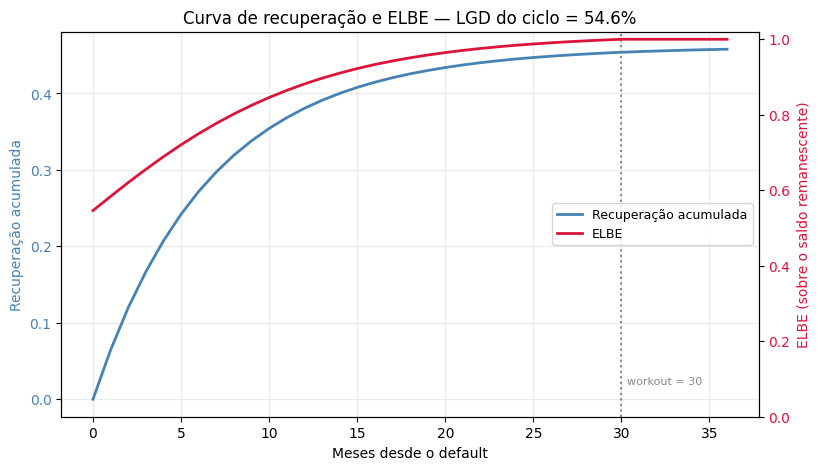

In [16]:
fig = tab.plot()          # o gráfico do pacote: recuperação + ELBE em eixos gêmeos

---
## 6 · Como se fixa a recuperação do ciclo completo (`ultimate`)

O numerador da ELBE é `1 − r̄(T*)`. Três formas de fixar essa recuperação:

| `ultimate` | lê `r̄` em | quando usar |
|---|---|---|
| `"workout"` (padrão) | o horizonte de achatamento `T*` | base maior naquele ponto, leitura mais robusta |
| `"last"` | o último mês da janela | mais dado, base menor e mais ruidosa |
| `float` | valor imposto | assíntota vinda de um estudo de longo prazo |

In [17]:
pd.DataFrame([
    {"ultimate": "workout (padrão)", **{"LGD": elbe_table(defaults).lgd,
                                        "ELBE(0)": elbe_table(defaults).frame["elbe"].iloc[0]}},
    {"ultimate": "last", **{"LGD": elbe_table(defaults, ultimate="last").lgd,
                            "ELBE(0)": elbe_table(defaults, ultimate="last").frame["elbe"].iloc[0]}},
    {"ultimate": "imposto 0,45", **{"LGD": elbe_table(defaults, ultimate=0.45).lgd,
                                    "ELBE(0)": elbe_table(defaults, ultimate=0.45).frame["elbe"].iloc[0]}},
]).round(4)

,ultimate,LGD,ELBE(0)
0,workout (padrão),0.5461,0.5461
1,last,0.5421,0.5421
2,"imposto 0,45",0.5500,0.5500


### Por que `ELBE(T*) = 1`

Com `ultimate="workout"`, a ELBE do **próprio `T*`** vale exatamente 1 — e isso é a
consequência **correta** da definição, não um defeito: se a recuperação do ciclo completo é
a que se observa até `T*`, então quem chegou a `T*` sem recuperar **não recupera mais**, e o
saldo remanescente é perda inteira.

É o que faz a curva de ELBE subir do nível da LGD até 1 ao longo da cobrança. Quem preferir
uma cauda menos abrupta usa `ultimate="last"` ou impõe a assíntota de um estudo próprio.

In [18]:
comparacao_ult = pd.DataFrame({
    modo: elbe_table(defaults, ultimate=valor).frame["elbe"]
    for modo, valor in [("workout", "workout"), ("last", "last"), ("imposto 0,45", 0.45)]
})
comparacao_ult.iloc[[0, 12, 24, 28, 32, 36]].round(4)

,workout,last,"imposto 0,45"
mes_default,,,
0,0.5461,0.5421,0.5500
12,0.8816,0.8751,0.8879
24,0.9841,0.9769,0.9911
28,0.9959,0.9886,1.0000
32,1.0000,0.9957,1.0000
36,1.0000,1.0000,1.0000


---
## 7 · Desconto, *add-on* e piso

### Desconto (obrigatório sob 4.966 / IFRS 9)

As recuperações futuras entram a **valor presente**. Cada recuperação **marginal** do mês
`t` é descontada por `(1 + i)^(−t/12)` antes de agregar — a acumulada bruta **não** se
desconta em bloco, porque cada parcela dela veio de um mês diferente.

In [19]:
taxas = [0.0, 0.06, 0.12, 0.18, 0.30]
efeito = pd.DataFrame([
    {"taxa efetiva a.a.": i,
     "recuperação no workout": elbe_table(defaults, discount_rate=i).ultimate_recovery,
     "LGD do ciclo": elbe_table(defaults, discount_rate=i).lgd}
    for i in taxas
])
efeito["Δ LGD vs nominal"] = efeito["LGD do ciclo"] - efeito["LGD do ciclo"].iloc[0]
efeito.round(4)

,taxa efetiva a.a.,recuperação no workout,LGD do ciclo,Δ LGD vs nominal
0,0.00,0.4539,0.5461,0.0000
1,0.06,0.4382,0.5618,0.0157
2,0.12,0.4241,0.5759,0.0298
3,0.18,0.4114,0.5886,0.0425
4,0.30,0.3905,0.6095,0.0634


Quanto mais lenta a recuperação, mais o desconto pesa — o dinheiro que chega no mês 30 vale
menos que o do mês 3. Por isso a **velocidade** do *workout* é tão relevante quanto o total
recuperado.

### *Add-on* de perda inesperada → LGD *in default*

As diretrizes (EBA/GL/2017/16 §6) exigem que a LGD dos ativos em *default* reconheça a
possibilidade de as recuperações virem **piores** que a melhor estimativa. A LGD *in
default* é a ELBE mais esse acréscimo:

`LGD_in_default = min(1, ELBE + addon)`, com `floor` opcional.

`addon = 0` iguala as duas — e precisa ser **justificado**.

In [20]:
com_addon = elbe_table(defaults, addon=0.08, floor=None)
com_piso = elbe_table(defaults, addon=0.08, floor=0.75)
pd.DataFrame({
    "ELBE": com_addon.frame["elbe"],
    "LGD in default (addon 8 p.p.)": com_addon.frame["lgd_in_default"],
    "LGD in default (+ piso 75%)": com_piso.frame["lgd_in_default"],
}).iloc[[0, 6, 12, 24, 36]].round(4)

,ELBE,LGD in default (addon 8 p.p.),LGD in default (+ piso 75%)
mes_default,,,
0,0.5461,0.6261,0.7500
6,0.7500,0.8300,0.8300
12,0.8816,0.9616,0.9616
24,0.9841,1.0000,1.0000
36,1.0000,1.0000,1.0000


---
## 8 · Estornos: quando a acumulada **cai** de verdade

Recuperação marginal negativa acontece: estorno, revisão de garantia, reclassificação. O
módulo **conta** as reversões e deixa a decisão explícita.

| `monotonic` | o que faz |
|---|---|
| `"none"` (padrão) | respeita o dado e apenas conta |
| `"clip"` | zera as marginais negativas |
| `"error"` | recusa — força a decisão antes de seguir |

In [21]:
com_estorno = defaults.copy()
alvo = com_estorno.index[:120]
com_estorno.loc[alvo, "lgd_m8"] = com_estorno.loc[alvo, "lgd_m7"] + 0.06   # estorno no mês 8

print("reversões detectadas:", int(recovery_curve(com_estorno)["n_reversoes"].sum()))
pd.DataFrame([
    {"monotonic": "none (respeita)", "LGD": elbe_table(com_estorno, monotonic="none").lgd},
    {"monotonic": "clip (zera)", "LGD": elbe_table(com_estorno, monotonic="clip").lgd},
]).round(5)

reversões detectadas: 107


,monotonic,LGD
0,none (respeita),0.54600
1,clip (zera),0.53638


In [22]:
try:
    elbe_table(com_estorno, monotonic="error")
except ValueError as e:
    print("monotonic='error' ->", str(e)[:150])

monotonic='error' -> 107 recuperação(ões) marginal(is) negativa(s) (a acumulada cai de um mês para o outro). Use monotonic='clip' para zerá-las ou 'none' para respeitar o 


---
## 9 · Por segmento

Agregar recuperações muito diferentes numa curva só é o erro clássico desta tabela: a
cobrança de cartão sem garantia e a de consignado com margem não têm nem o mesmo nível nem
a mesma velocidade.

In [23]:
tabs = elbe_table(defaults, by="segmento", addon=0.05, discount_rate=0.12)
pd.DataFrame({seg: {"n contratos": t.meta["n_contratos"],
                    "LGD do ciclo": t.lgd,
                    "recuperação no workout": t.ultimate_recovery,
                    "workout (meses)": t.workout,
                    "ELBE(0)": t.frame["elbe"].iloc[0]}
              for seg, t in tabs.items()}).T.round(4)

,n contratos,LGD do ciclo,recuperação no workout,workout (meses),ELBE(0)
cartao,513.0,0.7012,0.2988,29.0,0.7012
consignado,287.0,0.3340,0.6660,25.0,0.3340


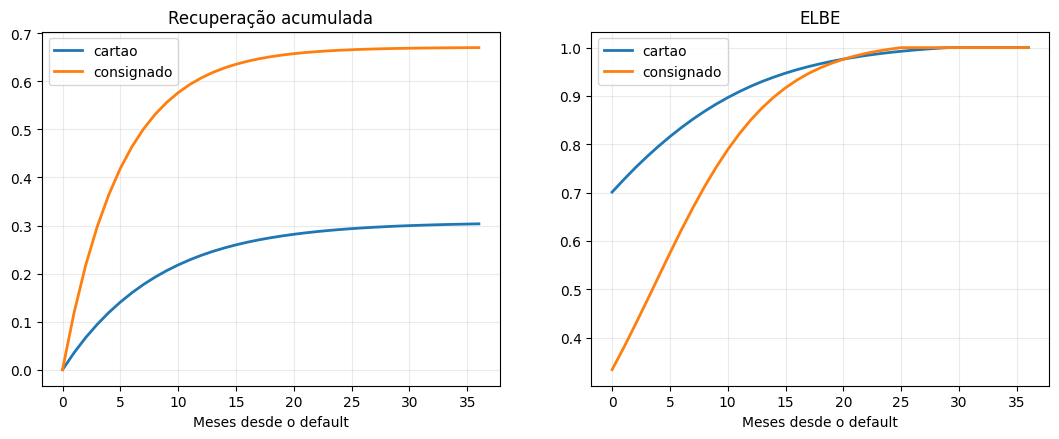

In [24]:
fig, eixos = plt.subplots(1, 2, figsize=(13, 4.6))
for seg, t in tabs.items():
    eixos[0].plot(t.frame.index, t.frame["recuperacao_acumulada"], lw=2, label=seg)
    eixos[1].plot(t.frame.index, t.frame["elbe"], lw=2, label=seg)
eixos[0].set_title("Recuperação acumulada"); eixos[1].set_title("ELBE")
for ax in eixos:
    ax.set_xlabel("Meses desde o default"); ax.grid(alpha=.25); ax.legend()
plt.show()

In [25]:
from yggdrasil.credit_risk.ecl import elbe_frame

# A forma longa é a que vai para o relatório e para o join com a carteira.
elbe_frame(tabs)[["segmento", "mes_default", "n_contratos",
                  "recuperacao_acumulada", "elbe", "lgd_in_default"]].head(4).round(4)

,segmento,mes_default,n_contratos,recuperacao_acumulada,elbe,lgd_in_default
0,cartao,0,513,0.0000,0.7012,0.7512
1,cartao,1,513,0.0352,0.7267,0.7767
2,cartao,2,513,0.0667,0.7513,0.8013
3,cartao,3,484,0.0942,0.7741,0.8241


---
## 10 · Aplicar à carteira viva em *default*

Cada contrato recebe a ELBE e a LGD *in default* do **seu tempo em *default*** (e do seu
segmento). Com o **saldo atual** — não a exposição na data do *default* — sai também a
perda esperada em moeda, que é o que vai para o estágio 3 do ECL.

In [26]:
from yggdrasil.credit_risk.ecl import apply_elbe

rng = np.random.default_rng(3)
vivos = pd.DataFrame({
    "id_contrato": [f"V{i:03d}" for i in range(8)],
    "segmento": ["cartao", "consignado"] * 4,
    "meses_em_default": [0, 1, 6, 12, 18, 24, 36, 120],      # o 120 é clipado na tabela
    "saldo": rng.lognormal(8.0, 0.4, 8).round(2),
})
escorados = apply_elbe(vivos, tabs, months_col="meses_em_default",
                       exposure_col="saldo", segment_col="segmento")
escorados.round(4)

,id_contrato,segmento,meses_em_default,saldo,elbe,lgd_in_default,perda_esperada
0,V000,cartao,0,6743.72,0.7012,0.7512,4728.5765
1,V001,consignado,1,1072.49,0.3790,0.4290,406.5262
2,V002,cartao,6,3523.60,0.8347,0.8847,2941.2790
3,V003,consignado,12,2375.33,0.8507,0.9007,2020.6028
4,V004,cartao,18,2487.27,0.9666,1.0000,2404.1560
5,V005,consignado,24,2734.66,0.9968,1.0000,2725.9253
6,V006,cartao,36,1328.77,1.0000,1.0000,1328.7700
7,V007,consignado,120,2716.85,1.0000,1.0000,2716.8500


In [27]:
print(f"perda esperada total (estágio 3): {escorados['perda_esperada'].sum():,.2f}")
print(f"sobre um saldo de ..............: {escorados['saldo'].sum():,.2f}")
print(f"cobertura ......................: {escorados['perda_esperada'].sum() / escorados['saldo'].sum():.2%}")

perda esperada total (estágio 3): 19,272.69
sobre um saldo de ..............: 22,982.69
cobertura ......................: 83.86%


---
## 11 · Registro no MLflow

In [28]:
import mlflow
from yggdrasil.credit_risk.ecl import log_elbe

mlflow.set_tracking_uri("file:./mlruns")
run_id = log_elbe(tab, experiment="/Shared/Yggdrasil/elbe_tutorial", run_name="elbe_carteira")
print("run:", run_id)
print("parâmetros logados:", {k: tab.meta[k] for k in ("kind", "ultimate", "addon",
                                                       "discount_rate", "cohort", "tol")})

2026/08/16 14:28:08 INFO mlflow.tracking.fluent: Experiment with name '/Shared/Yggdrasil/elbe_tutorial' does not exist. Creating a new experiment.


run: 7471053eff404f918400eb403383fec0
parâmetros logados: {'kind': 'lgd', 'ultimate': 'workout', 'addon': 0.0, 'discount_rate': None, 'cohort': 'chained', 'tol': 0.005}


---
## Resumo

| grandeza | fórmula | natureza |
|---|---|---|
| recuperação acumulada | `r̄(t)`, **encadeada** e ponderada por exposição | descritiva |
| LGD acumulada | `1 − r̄(t)` | **retrospectiva** — quanto já se perdeu |
| **ELBE** | `(1 − r̄(T*)) / (1 − r̄(t))` | **prospectiva** — quanto ainda falta |
| LGD *in default* | `ELBE + add-on` | prospectiva, com perda inesperada |

**Os três cuidados que o módulo trata explicitamente:**

1. **ponderação por exposição** — a média simples das LGDs individuais não é a LGD da
   carteira;
2. **coorte variável** — cada mês é estimado nos contratos que chegaram nele, encadeando a
   recuperação marginal; a média direta cai quando o tempo de observação se correlaciona
   com a qualidade da recuperação (e ele se correlaciona);
3. **horizonte de *workout*** — a recuperação não é infinita, e é no achatamento que se lê
   a LGD do ciclo completo.

**E o erro clássico que ele existe para desmontar:** `1 − r̄(t)` **não** é a ELBE.

| próximo passo | |
|---|---|
| [`15`](15_tutorial_ccf.ipynb) | **CCF/EAD** — sobre qual exposição a perda incide |
| [`13`](13_tutorial_pd_lifetime.ipynb) | **PD lifetime** — quando o risco se materializa |
| [`12`](12_tutorial_ecl.ipynb) | os três juntos na **tabela de ECL** |